In [2]:
import jax
import jax.numpy as jnp

# 1st version, dense Cholesky

In [3]:
a1 = jnp.array([1.,2.,3.])
a2 = jnp.array([3.,5.,6.])
a3 = jnp.array([2.,7.,4.])
a4 = jnp.array([2.,8.,7.])

A1 = jnp.outer(a1, a1)
A2 = jnp.outer(a2, a2)
A3 = jnp.outer(a3, a3)
A4 = jnp.outer(a4, a4)

A_base = A1+A2+A3

A_base

Array([[14., 31., 29.],
       [31., 78., 64.],
       [29., 64., 61.]], dtype=float32)

In [4]:
assert jnp.all(jnp.linalg.eigvalsh(A_base) > 0), "Not PD"
assert jnp.all(A_base == A_base.T), "Not Symmetric"

In [5]:
L = jnp.linalg.cholesky(A_base)
R = jnp.linalg.cholesky(A_base, upper=True)

R.T@R.T, jnp.abs(R.T@R - A_base)

(Array([[14.000001  ,  0.        ,  0.        ],
        [56.343666  ,  9.35715   ,  0.        ],
        [35.868504  , -0.28160676,  0.9236643 ]], dtype=float32),
 Array([[9.5367432e-07, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 3.8146973e-06],
        [0.0000000e+00, 3.8146973e-06, 0.0000000e+00]], dtype=float32))

In [6]:
Rp = jax.lax.linalg.cholesky_update(R, a4)

R2 = jnp.linalg.cholesky(A_base+A4, upper=True)

Rp,R2

(Array([[ 4.2426410e+00,  1.1078006e+01,  1.0135198e+01],
        [ 0.0000000e+00,  4.3906474e+00,  1.7587900e+00],
        [ 0.0000000e+00, -4.6474074e-08,  2.0455894e+00]], dtype=float32),
 Array([[ 4.2426405, 11.078007 , 10.135198 ],
        [ 0.       ,  4.3906455,  1.7587875],
        [ 0.       ,  0.       ,  2.0455892]], dtype=float32))

In [7]:
"""
Efficient rank-1 Cholesky downdate in JAX (Stewart-style / cholupdate-style)

Implements an O(n^2) in-place-like downdate for lower-triangular Cholesky factors.

Given L (lower-triangular, positive diagonal) with A = L @ L.T, and a vector v,
compute L_new such that L_new @ L_new.T = A - v v^T, when this remains SPD.

Also exposes a symmetric API for rank-1 update for completeness.

Notes
-----
* The algorithm mirrors the classic cholupdate/downdate scheme using plane
  rotations (Givens) applied to the (k,k) pivot and the working vector.
* We include a positive-definiteness guard for downdates based on
  rho^2 = 1 - ||solve(L, v)||^2 > 0. If this fails, we return (L, False).
* Written with JAX transforms in mind (jit-friendly, no Python loops after jitting).

References
----------
- Stewart (dchud/dchdd); Seeger (2008) "Low Rank Updates for the Cholesky Decomposition".
"""
from __future__ import annotations
from typing import Tuple
import jax
import jax.numpy as jnp
import jax.scipy as jsp
from jax import lax

Array = jax.Array


def _rank1_modify_lower(L: Array, x: Array, sign: float) -> Tuple[Array, Array, Array]:
    """Core O(n^2) rank-1 modify (update/downdate) for LOWER-triangular L.

    JIT-friendly: avoids dynamic-length slicing inside the loop. We do full-width
    vector updates gated by a boolean mask (idx > k) so shapes remain static.
    """
    n = L.shape[0]

    def body(k, carry):
        Lk, xk, ok = carry
        Lkk = Lk[k, k]
        xk_k = xk[k]
        # r^2 = Lkk^2 +/- xk_k^2
        r2 = Lkk * Lkk + sign * (xk_k * xk_k)
        ok_k = (r2 > 0.0) | (sign > 0.0)  # only relevant for downdate
        r = jnp.sqrt(jnp.maximum(r2, 0.0))
        # Givens parameters
        c = jnp.where(Lkk != 0.0, r / Lkk, 1.0)
        s = jnp.where(Lkk != 0.0, xk_k / Lkk, 0.0)
        # Set the pivot
        Lk = Lk.at[k, k].set(r)
        # Vectorized update for rows j > k
        idx = jnp.arange(n)
        mask = idx > k
        Lcol = Lk[:, k]
        Lcol_new = jnp.where(mask, (Lcol + sign * s * xk) / c, Lcol)
        # Ensure diagonal just set remains r
        Lcol_new = Lcol_new.at[k].set(r)
        Lk = Lk.at[:, k].set(Lcol_new)
        # Update x: x_j <- c * x_j - s * L_{j,k}^{new} for j > k; x_k <- 0
        x_new = jnp.where(mask, c * xk - s * Lcol_new, xk)
        x_new = x_new.at[k].set(0.0)
        ok = ok & ok_k
        return (Lk, x_new, ok)

    L_out, x_out, ok = lax.fori_loop(0, n, body, (L, x, jnp.array(True)))
    return L_out, x_out, ok


@jax.jit
def cholesky_update_lower(L: Array, v: Array) -> Array:
    """Rank-1 update: return L' s.t. L' L'^T = (L L^T) + v v^T.

    Parameters
    ----------
    L : (n, n) lower-triangular Cholesky factor (diag>0)
    v : (n,) update vector
    """
    L_new, _, _ = _rank1_modify_lower(L, v, sign=+1.0)
    # Ensure positive diagonal (guard against round-off)
    diag = jnp.sign(jnp.diag(L_new))
    diag = jnp.where(diag == 0.0, 1.0, diag)
    L_new = L_new * diag[:, None]
    return L_new


from functools import partial

@partial(jax.jit, static_argnames=("check_pd",))
def cholesky_downdate_lower(L: Array, v: Array, check_pd: bool = True) -> Tuple[Array, Array]:
    """Rank-1 downdate: return (L', ok) with L' L'^T = (L L^T) - v v^T when ok=True.

    JIT notes
    ---------
    * `check_pd` is a **static** Python bool (compiled into the XLA program).
      Pass a Python literal True/False; do not pass a JAX boolean array.
    * SPD guard uses jax.scipy's `solve_triangular` with RHS shape (n,),
      which sidesteps shape pitfalls.
    """
    if check_pd:
        # Pre-check: rho^2 = 1 - ||L^{-1} v||^2 > 0
        p = jsp.linalg.solve_triangular(L, v, lower=True, trans='N')
        rho2 = 1.0 - jnp.dot(p, p)
        ok0 = rho2 > 0.0
    else:
        ok0 = jnp.array(True)

    L_new, _, ok_alg = _rank1_modify_lower(L, v, sign=-1.0)
    ok = ok0 & ok_alg

    # Enforce positive diagonal convention without materializing a dense D
    diag = jnp.sign(jnp.diag(L_new))
    diag = jnp.where(diag == 0.0, 1.0, diag)
    L_new = L_new * diag[:, None]
    return L_new, ok


# Sequential series of up-/downdates on a single factor (mixed signs)
from functools import partial as __partial

@__partial(jax.jit, static_argnames=("check_pd",))
def cholesky_modify_lower_series(L: Array, V: Array, signs: Array, check_pd: bool = True) -> Tuple[Array, Array, Array]:
    """Apply a sequence of rank-1 up-/downdates to a single lower-triangular factor.

    Parameters
    ----------
    L     : (n, n) lower-triangular Cholesky factor (diag>0)
    V     : (m, n) sequence of vectors v_k
    signs : (m,)   +1.0 for update (A + v v^T), -1.0 for downdate (A - v v^T)
    check_pd : if True, guard each downdate step k with rho^2_k = 1 - ||L_k^{-1} v_k||^2 > 0.

    Returns
    -------
    L_final : (n, n) factor after applying the *valid* prefix of operations
    ok_all  : scalar bool; True iff all steps were valid
    ok_each : (m,) bool flags per step (True if step was valid wrt SPD + algebra)

    Notes
    -----
    * If a step is invalid (downdate would break SPD), it is skipped and all subsequent
      steps are also skipped; `ok_each[k]` marks the first failure.
    * This function is JIT-friendly (static shapes, `lax.scan`).
    """
    signs = signs.astype(V.dtype)

    def scan_step(carry, inp):
        Lk, ok_so_far = carry
        v_k, s_k = inp

        if check_pd:
            def _guard_true(_):
                p = jsp.linalg.solve_triangular(Lk, v_k, lower=True, trans='N')
                rho2 = 1.0 - jnp.dot(p, p)
                return rho2 > 0.0
            ok_guard = lax.cond(s_k < 0.0, _guard_true, lambda _: jnp.array(True), operand=None)
        else:
            ok_guard = jnp.array(True)

        L_new, _, ok_alg = _rank1_modify_lower(Lk, v_k, sign=s_k)
        # Keep positive diagonal convention
        diag = jnp.sign(jnp.diag(L_new))
        diag = jnp.where(diag == 0.0, 1.0, diag)
        L_new = L_new * diag[:, None]

        ok_step = ok_guard & ok_alg
        apply = ok_so_far & ok_step
        L_next = lax.select(apply, L_new, Lk)
        ok_next = ok_so_far & ok_step
        return (L_next, ok_next), ok_step

    (L_final, ok_all), ok_each = lax.scan(scan_step, (L, jnp.array(True)), (V, signs))
    return L_final, ok_all, ok_each

@jax.jit
def cholesky_update_lower_series(L: Array, V: Array) -> Tuple[Array, Array, Array]:
    """Sequence of rank-1 **updates** (sign=+1) on a single factor.

    Returns (L_final, ok_all, ok_each); all ok flags should be True for updates.
    """
    m = V.shape[0]
    signs = jnp.ones((m,), dtype=V.dtype)
    return cholesky_modify_lower_series(L, V, signs, check_pd=False)

@__partial(jax.jit, static_argnames=("check_pd",))
def cholesky_downdate_lower_series(L: Array, V: Array, check_pd: bool = True) -> Tuple[Array, Array, Array]:
    """Sequence of rank-1 **downdates** (sign=-1) on a single factor.

    Returns (L_final, ok_all, ok_each) with SPD guards per step if `check_pd=True`.
    """
    m = V.shape[0]
    signs = -jnp.ones((m,), dtype=V.dtype)
    return cholesky_modify_lower_series(L, V, signs, check_pd=check_pd)


In [8]:
jnp.max(jnp.abs( cholesky_update_lower(L, a4) - R2.T ))

Array(1.9073486e-06, dtype=float32)

In [9]:
Lp, ok = cholesky_downdate_lower(cholesky_update_lower(L, a4), a4, check_pd=True)
assert ok, "downdating failed!"

jnp.max(jnp.abs( Lp - L )) 

Array(6.631017e-07, dtype=float32)

In [10]:
from matfree import decomp, funm

def assert_pd(M):
    assert jnp.all(jnp.linalg.eigvals(M) > 0), "Not PD!"
    
def assert_sym(M):
    assert jnp.all(M == M.T) or jnp.all(jnp.isclose(M, M.T, atol=1e-7)), "Not symmmetric!"
    
def assert_spd(M):
    assert_sym(M)
    assert_pd(M)

In [11]:
from jax.flatten_util import ravel_pytree

# ======== Clean subspace-augmentation + re-tridiagonalization (no fori_loop) ========

def _orth_against(Q: jax.Array, Y: jax.Array, eps: float = 1e-12) -> jax.Array:
    # Orthonormal basis for (I-QQ^T)Y
    Yp = Y - Q @ (Q.T @ Y)
    if Yp.size == 0:
        return Yp
    U, R = jnp.linalg.qr(Yp, mode="reduced")
    if R.size == 0:
        return U[:, :0]
    keep = jnp.abs(jnp.diag(R)) > eps * jnp.linalg.norm(R, ord=2)
    return U[:, keep]


def _build_Z_or_R(Q_or_U, wt_apply):
    YQ_or_U = jax.vmap(wt_apply, in_axes=1, out_axes=1)(Q_or_U)     # (k, m)
    Mat  = YQ_or_U.T                                             # (m, k)
    return Mat


def augment_and_retridiag(Q: jax.Array,
                          T: jax.Array,
                          w_apply, 
                          wt_apply,
                          v0=None,
                          sign: float = +1.0,
                          mode: str = "exact",
                          probes: int = 0,
                          key = jax.random.PRNGKey(0)):
    """
    Given A ≈ Q T Q^T and a low-rank ± W W^T (via oracles w_apply, wt_apply),
    return (Q_tilde, T_tilde) with T_tilde tridiagonal so that
      A' ≈ Q_tilde T_tilde Q_tilde^T.
    - mode="exact": spans range(W) exactly by applying W to I_k (needs latent dim k).
    - mode="random": spans (I-QQ^T)range(W) via 'probes' random latent vectors.
    """
    m = Q.shape[1]
    D = Q.shape[0]
    # k_latent = _infer_k(wt_apply, D) # TODO compute once and pass from outside
    vflat,unravel_fn = ravel_pytree(wt_apply(jnp.zeros((D,))))
    k_latent = int(vflat.shape[0])
    
    # Z = Q^T W from W^T only
    Z = _build_Z_or_R(Q, wt_apply).squeeze()

    # Build residual basis U for (I-QQ^T)range(W)
    if mode == "exact":
        I_k = jnp.eye(k_latent, dtype=Q.dtype) # ! Problem.
        Y   = jax.vmap(lambda v: w_apply(unravel_fn(v)), in_axes=1, out_axes=1)(I_k)  # W * I_k  (D, k)
        U   = _orth_against(Q, Y)
    else:
        s   = probes if probes > 0 else min(k_latent, 6)     # a few probes by default
        Omega = jax.random.normal(key, (k_latent, s))
        Y     = jax.vmap(lambda v: w_apply(unravel_fn(v)), in_axes=1, out_axes=1)(Omega)  # (D, s)
        U     = _orth_against(Q, Y)

    r = 0 if U.size == 0 else U.shape[1]
    R = _build_Z_or_R(U, wt_apply).squeeze()

    # Assemble small augmented matrix \bar T
    T11 = T + sign * (Z.T @ Z)
    T12 = sign * (Z.T @ R)
    T22 = sign * (R.T @ R)
    Tbar = jnp.block([[T11, T12],
                      [T12.T, T22]])           # (m+r, m+r)
    
    """# ? Old, did not work for my GGN,W,WT operators
    # T11 = T + sign * (Z @ Z.T)
    # T12 = sign * (Z @ R.T)
    # T22 = sign * (R @ R.T)
    # Tbar = jnp.block([[T11, T12],
    #                   [T12.T, T22]])           # (m+r, m+r) """

    # Re-tridiagonalize \bar T using matfree's Lanczos on the small operator
    n_small = Tbar.shape[0]
    tridiag_small = decomp.tridiag_sym(n_small)
    def matvec_small(g):  # R^{m+r} -> R^{m+r}
        return Tbar @ g
    v0_small = jax.random.normal(key, (n_small,))
    res_small = tridiag_small(matvec_small, v0_small)
    Q_small   = res_small.Q_tall     # (m+r, m+r) orthogonal
    J_small   = res_small.J_small    # (m+r, m+r) tridiagonal

    Qbar   = Q if r == 0 else jnp.concatenate([Q, U], axis=1)  # (D, m+r)
    Qtilde = Qbar @ Q_small                                     # (D, m+r)
    Ttilde = J_small
    
    ZR = jnp.vstack([Z.T, R])
    F_block = Q_small.T @ ZR                                    # (m+r, k)
    
    return Qtilde, Ttilde, F_block, sign


def remove_block_and_shrink(Qtilde: jax.Array,
                            Ttilde: jax.Array,
                            F_block: jax.Array,
                            sign: float = +1.0,
                            target_M: int | None = None,
                            key = jax.random.PRNGKey(1)):
    """
    Downdate by the saved block and reduce basis size.

    Inputs:
      Qtilde (D, n), Ttilde (n, n) tridiagonal from 'augment_and_retridiag_with_block'
      F_block (n, r_*): the exact block added in small coords
      sign: the same sign used when adding (+1 for update, -1 for downdate)
      target_M: keep this many directions (default: n - rank(F_block))

    Returns:
      Q_shrunk (D, M), T_shrunk (M, M) tridiagonal
    """
    n = int(Ttilde.shape[0])
    r_star = int(F_block.shape[1])
    if target_M is None:
        target_M = n - r_star

    # Remove the exact block inside the small space
    T_minus = Ttilde - sign * (F_block @ F_block.T)

    # Deflate: keep the M largest |eigenvalues| (robust to tiny roundoff)
    evals, Ue = jnp.linalg.eigh(T_minus)              # symmetric small problem
    idx = jnp.argsort(jnp.abs(evals))[::-1][:target_M]
    lam_keep = evals[idx]                             # (M,)
    U_keep   = Ue[:, idx]                             # (n, M)

    # Compressed ambient basis
    Qc = Qtilde @ U_keep                              # (D, M)

    # Re-tridiagonalize within span(Qc) so we keep a Lanczos triple
    triM = decomp.tridiag_sym(target_M)
    def matvec_restricted(x):
        y = Qc.T @ x          # (M,)
        y = lam_keep * y      # (M,)
        return Qc @ y         # (D,)
    v0 = jax.random.normal(key, (Qc.shape[0],))
    res = triM(matvec_restricted, v0)
    Q_shrunk = res.Q_tall
    T_shrunk = res.J_small
    return Q_shrunk, T_shrunk


# 2nd version, Re-tridiagonalize / subspace projected updates

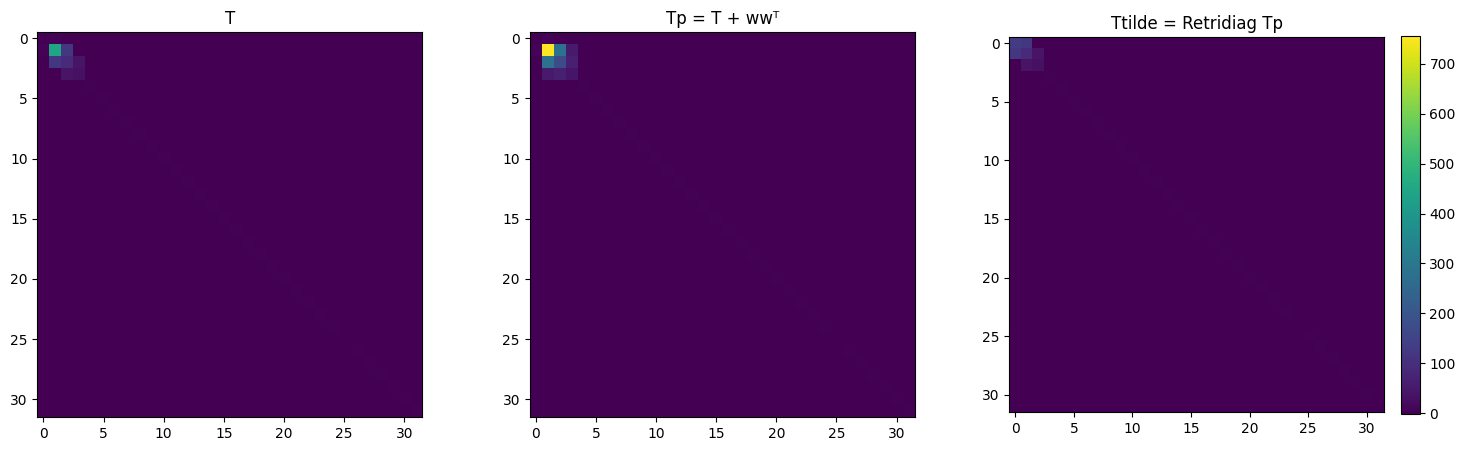

In [12]:
import jax
import jax.numpy as jnp

from jax.flatten_util import ravel_pytree
from typing import Tuple
import matplotlib.pyplot as plt

from matfree import decomp

jax.config.update('jax_enable_x64', True)



#* step 2: Bulge chase - seek orthogonal P s.t.     P.T (T ± w w.T) P = T', where T' tridiagonal.
def givens(a: jnp.ndarray, b: jnp.ndarray) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    r = jnp.hypot(a, b)
    c = jnp.where(r != 0.0, a / r, 1.0)
    s = jnp.where(r != 0.0, b / r, 0.0)
    return r, c, s


def sym_2x2_similar(dj, dj1, ej, c, s):
    """
    Apply symmetric similarity with [[c, s],[-s, c]] to the 2x2 block
    [[dj, ej],[ej, dj1]] and return updated (dj, dj1, ej).
    """
    c2, s2, cs = c*c, s*s, c*s
    djj   = c2*dj + 2*cs*ej + s2*dj1
    dj1j1 = s2*dj - 2*cs*ej + c2*dj1
    ejj   = (c2 - s2)*ej + cs*(dj1 - dj)
    return djj, dj1j1, ejj


def tridiag_rank1_modify(
    d: jnp.ndarray,
    e: jnp.ndarray,
    w: jnp.ndarray,
    sign: float,                 # ±1.0
    return_givens: bool = False,
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """
    Chase the bulge so that Q^T (T + sign * w w^T) Q is tridiagonal again.
    Inputs:
      d: main diagonal (n,)
      e: first off-diagonal (n-1,)
      w: vector from projecting u into Lanczos subspace (n,)
      sign: +1 or -1
    Returns:
      d_out, e_out, f_out (second off-diagonal produced during chase),
      cs_out, ss_out (Givens params per step; zeros if return_givens=False)
    """
    n = d.shape[0]
    dtype = d.dtype

    # Always allocate; if not requested we’ll just return zeros.
    cs_out = jnp.zeros((n-1,), dtype=dtype)
    ss_out = jnp.zeros((n-1,), dtype=dtype)
    f_init = jnp.zeros((n-2,), dtype=dtype)

    def body(j, carry):
        d_k, e_k, w_k, bulge_k, cs_k, ss_k, f_k = carry

        # Rotate w[j:j+2] to kill w[j+1].
        r, c, s = givens(w_k[j], w_k[j+1])
        w_k = w_k.at[j].set(r).at[j+1].set(0.0)

        # Left update (only if j > 0): absorb incoming bulge at position (j-1, j+1)
        def left_update(args):
            e_in, f_in, bulge = args
            e_im1_old = e_in[j-1]
            e_im1_new = c * e_im1_old + s * bulge
            bulge_left_new = bulge * c - s * e_im1_old  # goes to (j-1, j+1)
            e_out = e_in.at[j-1].set(e_im1_new)
            f_out = f_in.at[j-1].set(bulge_left_new)
            return e_out, f_out, bulge_left_new

        e_k, f_k, _ = jax.lax.cond(
            j > 0,
            left_update,
            lambda args: (args[0], args[1], jnp.asarray(0.0, dtype)),
            operand=(e_k, f_k, bulge_k),
        )

        # 2x2 symmetric similarity on (j, j+1)
        dj, dj1, ej = d_k[j], d_k[j+1], e_k[j]
        djj, dj1j1, ejj = sym_2x2_similar(dj, dj1, ej, c, s)
        d_k = d_k.at[j].set(djj).at[j+1].set(dj1j1)
        e_k = e_k.at[j].set(ejj)

        # Right update (only if j+1 < n-1): create new bulge at (j, j+2) and scale e[j+1]
        def right_update(args):
            e_in, f_in = args
            e_jp1_old = e_in[j+1]
            bulge_right_new = s * e_jp1_old
            e_out = e_in.at[j+1].set(c * e_jp1_old)
            f_out = f_in.at[j].set(bulge_right_new)
            return e_out, f_out, bulge_right_new

        e_k, f_k, bulge_next = jax.lax.cond(
            j + 1 < n - 1,
            right_update,
            lambda args: (args[0], args[1], jnp.asarray(0.0, dtype)),
            operand=(e_k, f_k),
        )

        # Optionally store Givens (cost is tiny; keep branch for clarity)
        cs_k = jax.lax.cond(
            return_givens,
            lambda v: v.at[j].set(c),
            lambda v: v,
            cs_k,
        )
        ss_k = jax.lax.cond(
            return_givens,
            lambda v: v.at[j].set(s),
            lambda v: v,
            ss_k,
        )

        return d_k, e_k, w_k, bulge_next, cs_k, ss_k, f_k

    d_out, e_out, w_out, _, cs_out, ss_out, f_out = jax.lax.fori_loop(
        0, n - 1,
        body,
        (d, e, w, jnp.asarray(0.0, dtype), cs_out, ss_out, f_init),
    )

    # rank-1 contribution after w has been rotated to [alpha, 0, ...]
    d_out = d_out.at[0].set(d_out[0] + sign * (w_out[0] * w_out[0]))

    # If givens weren’t requested, return 0-filled arrays to keep the same signature.
    if not return_givens:
        cs_out = jnp.zeros_like(cs_out)
        ss_out = jnp.zeros_like(ss_out)

    return d_out, e_out, f_out, cs_out, ss_out



def diag_indices(_D, k, ndim=2):
    assert ndim == 2, "Only implemented for ndim=2. Too bad."
    assert k < _D and k > -_D, "|k| must be less than _D (otherwise out of bounds = no indices)."
    diag_idx = jnp.diag_indices(_D, ndim=2)
    if k == 0:
        return diag_idx
    elif k > 0:
        _x = diag_idx[0][:-k]
        _y = diag_idx[1][:-k] + k
    elif k < 0:
        _x = diag_idx[0][:k] - k
        _y = diag_idx[1][:k]
    return _x,_y


_key = lambda i: jax.random.PRNGKey(i)

D = 1_000
rank = 64
M = 32

I_D = jnp.eye(D)
I_M = jnp.eye(M)


def rvec(key, d):
    return jax.random.bernoulli(key, p=0.4, shape=(d,)).astype(float)
    # return jax.random.normal(key, shape=(d,), dtype=float)

def rmat(key, d, d2):
    return jax.random.bernoulli(key, p=0.4, shape=(d,d2)).astype(float)
    # return jax.random.normal(key, shape=(d,d2), dtype=float)

def rank1(key, d):
    eps = rvec(key, d)
    return jnp.outer(eps, eps)

def mean_of_rank1s(key, rank, d):
    keys = jax.random.split(key, rank)
    return jax.vmap(lambda __key: rank1(__key, d))(keys).mean(axis=0)


# Test with a DxD that is probably full rank
# B = rmat(_key(1), D, rank)
# X = B@B.T + jnp.eye(D)

# Test with a DxD that is a sum of Rank-1 matrices and the identity matrix
R1_key = _key(443434)
R1 = rank1(R1_key, D)
X  = R1 + mean_of_rank1s(_key(442333), rank, D) + 1e-3 * jnp.eye(D)



def matvec(v):
    return X @ v
    

tridiag = decomp.tridiag_sym(M)

v = jax.random.normal(_key(5), (D,))

res = tridiag(matvec, v)
Q = res.Q_tall                  # (D, D2)
T = res.J_small                 # (D2, D2)


#* Step 1: add u u.T
# u = jax.random.normal(_key(112), shape=(D,))
u = rvec(R1_key, D)
w = Q.T@u
Tp = T + jnp.outer(w, w)


#* check that update in Lanczos space == update in original space
P = Q @ Q.T
assert jnp.all(
    jnp.isclose(
        (Q@Tp@Q.T),
        P@(X + jnp.outer(u,u))@P.T, 
        atol=1e-4
    )
)



d = jnp.diag(T)
e = jnp.diag(T, k=1)

dtilde, etilde, *_ = tridiag_rank1_modify(d, e, w, sign=-1.0)

Tbase = jnp.zeros((M,M)) \
    .at[diag_indices(M, k=0, ndim=2)].set(dtilde) \
    .at[diag_indices(M, k=1, ndim=2)].set(etilde) \
    .at[diag_indices(M, k=-1, ndim=2)].set(etilde)


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

_vmin = jnp.min(jnp.hstack([T, Tp, Tbase]))
_vmax = jnp.max(jnp.hstack([T, Tp, Tbase]))

im0 = axs[0].imshow(T,       vmin=_vmin, vmax=_vmax)
im1 = axs[1].imshow(Tp,      vmin=_vmin, vmax=_vmax)
im2 = axs[2].imshow(Tbase,  vmin=_vmin, vmax=_vmax)

fig.colorbar(im2, ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)

axs[0].set_title("T")
axs[1].set_title("Tp = T + wwᵀ")
axs[2].set_title("Ttilde = Retridiag Tp")

# plt.tight_layout()
plt.show()

# 3rd version, Givens rotate out / don't care about tridiagonal form

In [13]:
# --- Helpers -----------------------------------------------------------------

def build_tridiagonal(main, off):
    """Dense symmetric tridiagonal from its main and first off-diagonals."""
    return jnp.diag(main) + jnp.diag(off, 1) + jnp.diag(off, -1)

def lanczos_tridiag(matvec, v0, m):
    tri = decomp.tridiag_sym(m)
    out = tri(matvec, v0)
    Q, T = out.Q_tall, out.J_small
    return Q, T

def apply_sum_of_rank1_mods(d, e, C, sign):
    """
    Apply tridiag_rank1_modify once per row of C (each row is a vector w in R^m).
    This realizes a low-rank ±C^T C modification as a sum of rank-1 ±w w^T.
    """
    def step(carry, w):
        d_k, e_k = carry 
        d_k, e_k, *_ = tridiag_rank1_modify(d_k, e_k, w, sign=sign)
        return (d_k, e_k), None
    (d_out, e_out), _ = jax.lax.scan(step, (d, e), C)  # scan over rows
    return d_out, e_out

def eigvals_desc(A):
    return jnp.sort(jnp.linalg.eigvalsh(A))[::-1]

In [14]:
# givens_row.py
import jax
import jax.numpy as jnp
from jax import lax

# ---------- core utilities ----------
@jax.jit
def stack_zero_then_XT(X: jnp.ndarray) -> jnp.ndarray:
    """A = [[0]; X^T]  -> shape (M+1, D) for X in R^{D x M}."""
    return jnp.vstack([jnp.zeros((1, X.shape[0]), dtype=X.dtype), X.T])

@jax.jit
def rotate_rows(A: jnp.ndarray, i: int, j: int, c: float, s: float) -> jnp.ndarray:
    """Apply a single Givens to rows i and j of A (row-rotation)."""
    ri, rj = A[i], A[j]
    new_i = c * ri + s * rj
    new_j = -s * ri + c * rj
    A = A.at[i].set(new_i)
    A = A.at[j].set(new_j)
    return A

@jax.jit
def apply_row_givens_sequence(A: jnp.ndarray, c: jnp.ndarray, s: jnp.ndarray) -> jnp.ndarray:
    """Apply rotations (row 0, row k+1) for k=0..M-1 to A."""
    M = s.shape[0]
    def body(k, A_):
        return rotate_rows(A_, 0, k + 1, c[k], s[k])
    return lax.fori_loop(0, M, body, A)

def coeffs_from_thetas(thetas: jnp.ndarray) -> jnp.ndarray:
    """Compute a such that w = X a for the given thetas."""
    c, s = jnp.cos(thetas), jnp.sin(thetas)
    # suffix products of cosines: prod_{j>k} c_j
    suf = jnp.concatenate([jnp.cumprod(c[::-1])[::-1][1:], jnp.array([1.0], dtype=c.dtype)])
    return s * suf

@jax.jit
def givens_from_coeffs(a: jnp.ndarray, eps: float = 1e-12):
    """Back-solve s_k, c_k from a (requires ||a|| <= 1)."""
    M = a.shape[0]
    c = jnp.empty(M, dtype=a.dtype)
    s = jnp.empty(M, dtype=a.dtype)

    Cprod = 1.0
    # Python loop is fine here (O(M)); application is jitted.
    for k in range(M - 1, -1, -1):
        sk = a[k] / (Cprod + eps)
        sk = jnp.clip(sk, -1.0, 1.0)
        ck = jnp.sqrt(jnp.maximum(0.0, 1.0 - sk * sk))
        s = s.at[k].set(sk)
        c = c.at[k].set(ck)
        Cprod = Cprod * ck
    return c, s


# ---------- public API ----------
def apply_from_thetas(X: jnp.ndarray, thetas: jnp.ndarray):
    """Given X (D x M) and angles (M,), return (w, X_tilde)."""
    c, s = jnp.cos(thetas), jnp.sin(thetas)
    A = stack_zero_then_XT(X)
    GA = apply_row_givens_sequence(A, c, s)
    wT, XtildeT = GA[0], GA[1:]
    return wT, XtildeT.T, (c, s)


def rotations_for_w(X: jnp.ndarray, w: jnp.ndarray, tol: float = 1e-8):
    """
    Given X (D x M) and target w (D,), compute Givens (c,s) and apply them.
    Requires w in span(X) and the coefficient vector a to satisfy ||a|| <= 1.
    """
    a, *_ = jnp.linalg.lstsq(X, w, rcond=None)
    res = jnp.linalg.norm(X @ a - w)
    # if float(res) > tol:
    #     raise ValueError(f"w not in span(X) to tolerance (residual {float(res):.3e}).")
    if float(jnp.linalg.norm(a)) > 1.0 + 1e-10:
        raise ValueError("No exact row-Givens solution: need ||a|| ≤ 1.")
    c, s = givens_from_coeffs(a)
    A = stack_zero_then_XT(X)
    GA = apply_row_givens_sequence(A, c, s)
    wT, XtildeT = GA[0], GA[1:]
    return (c, s), (wT, XtildeT.T)


# ---------- optional: explicit G (rarely needed) ----------
def explicit_G(c: jnp.ndarray, s: jnp.ndarray) -> jnp.ndarray:
    """Build the (M+1)x(M+1) orthogonal matrix G (for debugging)."""
    M = c.shape[0]
    G = jnp.eye(M + 1)
    for k in range(M):
        B = jnp.eye(M + 1).at[(0, 0)].set(c[k]).at[(0, k + 1)].set(s[k]) \
                          .at[(k + 1, 0)].set(-s[k]).at[(k + 1, k + 1)].set(c[k])
        G = B @ G
    return G

In [15]:
jax.config.update('jax_enable_x64', True)


D    = 20
rank = 5
M    = 5



veps = rvec(_key(1234), D)
r1   = jnp.outer(veps, veps)                      # rank-1 “signal”
alpha = 1
iso_prior = alpha * jnp.eye(D)
mat0  = mean_of_rank1s(_key(4565), rank, D) # + iso_prior
mat  = r1 + mat0




vec = rvec(_key(789), D) 
def matvec(v): return mat @ v

Q, T = lanczos_tridiag(matvec, vec, M)
Tsqrt = jnp.linalg.cholesky(T + 1e-12*jnp.eye(len(T)))
X = Q @ Tsqrt                                      # shape (D, M)

(c, s), (wT, Xtilde) = rotations_for_w(X, veps)

mat0_hat = Xtilde@Xtilde.T

# assert jnp.all(
#     jnp.isclose(wT, veps)
# )

In [16]:
# _,ld = jnp.linalg.slogdet(mat)
# s1, res1 = jnp.linalg.slogdet(jnp.eye(M) + veps.T@jnp.linalg.pinv(mat0_hat)@veps)
# print(f"True logdet (mat)      = {ld:.1f}")
# print(f"Recon logdet (mat_hat) = {s1*res1:.1f}")

_,ld0 = jnp.linalg.slogdet(   iso_prior + mat0)        # A - ww^T
s0, res0 = jnp.linalg.slogdet(iso_prior + mat0_hat) # \tilde{X}\tilde{X}^T

print(f"True logdet (mat0)     = {ld0:.1f}")
print(f"Recon logdet(mat0_hat) = {s0*res0:.1f}")

True logdet (mat0)     = 3.8
Recon logdet(mat0_hat) = 3.1


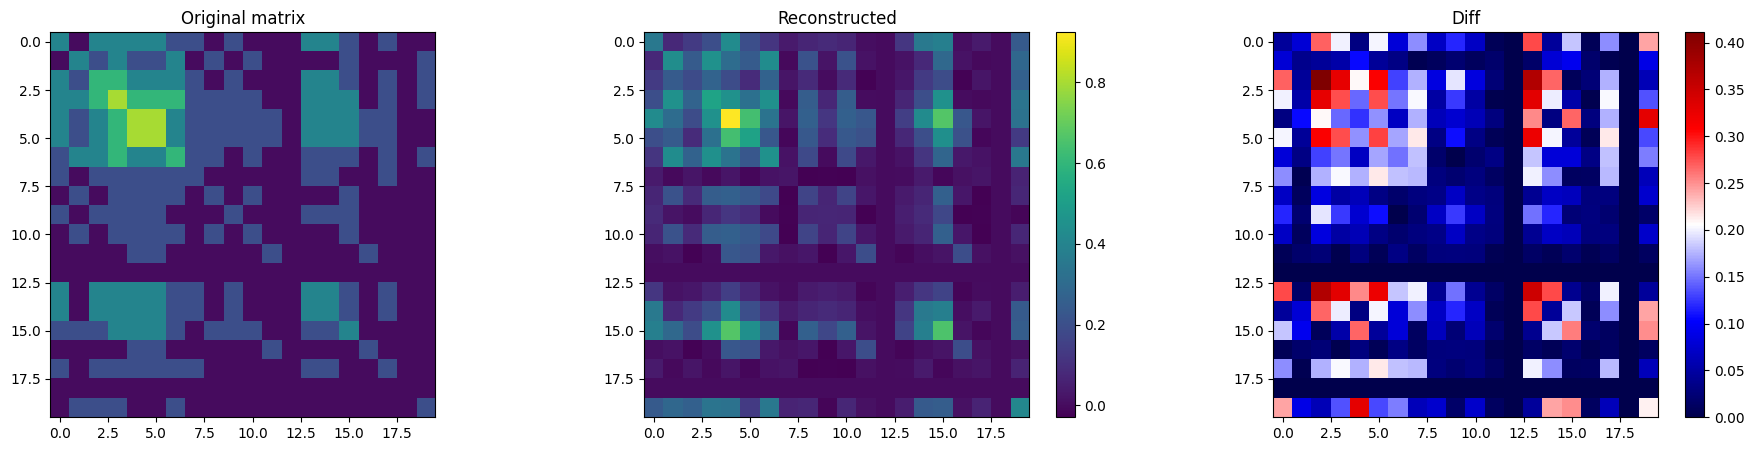

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(23,5))

diff = jnp.abs(mat0 - mat0_hat)


vmin = min(mat0.min(), mat0_hat.min())
vmax = max(mat0.max(), mat0_hat.max())

axs[0].imshow(mat0    , vmin=vmin, vmax=vmax)
cbar_tgt = axs[1].imshow(mat0_hat, vmin=vmin, vmax=vmax)
plt.colorbar(cbar_tgt)

cbar_tgt = axs[2].imshow(diff, cmap='seismic', vmin=0)#, vmax=1,)
plt.colorbar(cbar_tgt)

axs[0].set_title('Original matrix')
axs[1].set_title('Reconstructed')
axs[2].set_title('Diff')    

plt.show()

In [18]:
jnp.diag(mat0)

Array([0.4, 0.4, 0.6, 0.8, 0.8, 0.8, 0.6, 0.2, 0.2, 0.2, 0.2, 0.2, 0. ,
       0.4, 0.4, 0.4, 0.2, 0.2, 0. , 0.2], dtype=float64)

# Tests with GGN

In [19]:
jax.config.update('jax_enable_x64', False)

# load MAP state

import optax

from src.utils import load_checkpoint, load_yaml, count_model_params
from src.scalemodels import TrainState, EMPTY_STATS
from src.toymodels import SimpleClassifier
from src.toydata import get_dataloaders

dataset = 'banana'
model_name = f'toyclassifier_{dataset}'
cfg_path = f'config/toy/{model_name}.yml'

cfg = load_yaml(cfg_path)
model_cfg = cfg['model']
opt_cfg = cfg['optimization']
alpha = opt_cfg["alpha"]
map_cfg = opt_cfg["map"]

model_type = model_cfg.get("name", "regressor")  # 'regressor' or 'classifier'
num_h = model_cfg["num_h"]
num_l = model_cfg["num_l"]
num_c = model_cfg.get("num_c", 2) if model_type == "classifier" else 1
rng_model = jax.random.PRNGKey(model_cfg["seed"])
map_batch_size = 256 # map_cfg["batch_size"]
epochs_map = map_cfg["epochs"]
lr_map = map_cfg["lr"]

model = SimpleClassifier(numh=num_h, numl=num_l, numc=num_c)

train_loader, test_loader, _ = get_dataloaders(dataset=dataset, batch_size=map_batch_size)

dummy_input = next(iter(train_loader))[0][:1]
variables = model.init(rng_model, dummy_input)
optimizer_map = optax.adam(1e-3)
model_state = TrainState.create(
    apply_fn=model.apply,
    params=variables['params'],
    tx=optimizer_map,
    batch_stats = variables.get('batch_stats', EMPTY_STATS),
)
map_ckpt_prefix = f"map_{dataset}"

map_state = load_checkpoint(
    ckpt_dir="checkpoint/map/",
    prefix=map_ckpt_prefix,
    target=model_state
)

D = count_model_params(variables)

In [ ]:
# compute W and GGN

from src.ggn import compute_W_vps, compute_ggn_vp, compute_ggn_dense
from src.utils import flatten_nn_params

flat_params, unravel_fn = flatten_nn_params(map_state.params)

num_mod_terms = 40

FULL_DATA  = next(iter(train_loader))[0]
N = FULL_DATA.shape[0]
GGN_DATA   = FULL_DATA[:-num_mod_terms]
EXTRA_TERM = FULL_DATA[-num_mod_terms:]

GGN_full_dense, *_ =  compute_ggn_dense(map_state, FULL_DATA, model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
GGN_dense, *_      =  compute_ggn_dense(map_state, GGN_DATA,  model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)

GGN_full =  compute_ggn_vp(map_state, FULL_DATA,  model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
GGN      =  compute_ggn_vp(map_state, GGN_DATA,   model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
W, WT    =  compute_W_vps( map_state, GGN_DATA,   model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
Wp, WTp  =  compute_W_vps( map_state, EXTRA_TERM, model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)

In [ ]:
jax.config.update('jax_enable_x64', False)

D = count_model_params(variables) # 626
M = 35
key = _key(424242)

v0 = jax.random.normal(key, (D,))

Q, T = lanczos_tridiag(GGN_full, v0, M)
Tsqrt = jnp.linalg.cholesky(T + 1e-8*jnp.eye(len(T)))
X = Q @ Tsqrt


WTp_dense = jax.jacfwd(WTp)(v0) # shape = (B, O, D) = (data-batch, output size, D)
B,O,_ = WTp_dense.shape
Xtilde = X
print("WARNING: naïve python implementation, for-loops")
for b in range(B):
    for o in range(O):
        WTp_i = WTp_dense[b,o]
        (c, s), (wT, Xtilde) = rotations_for_w(Xtilde, WTp_i)

GGN_hat = Xtilde@Xtilde.T
# GGN_hat = GGN_full_dense

NameError: name 'jax' is not defined

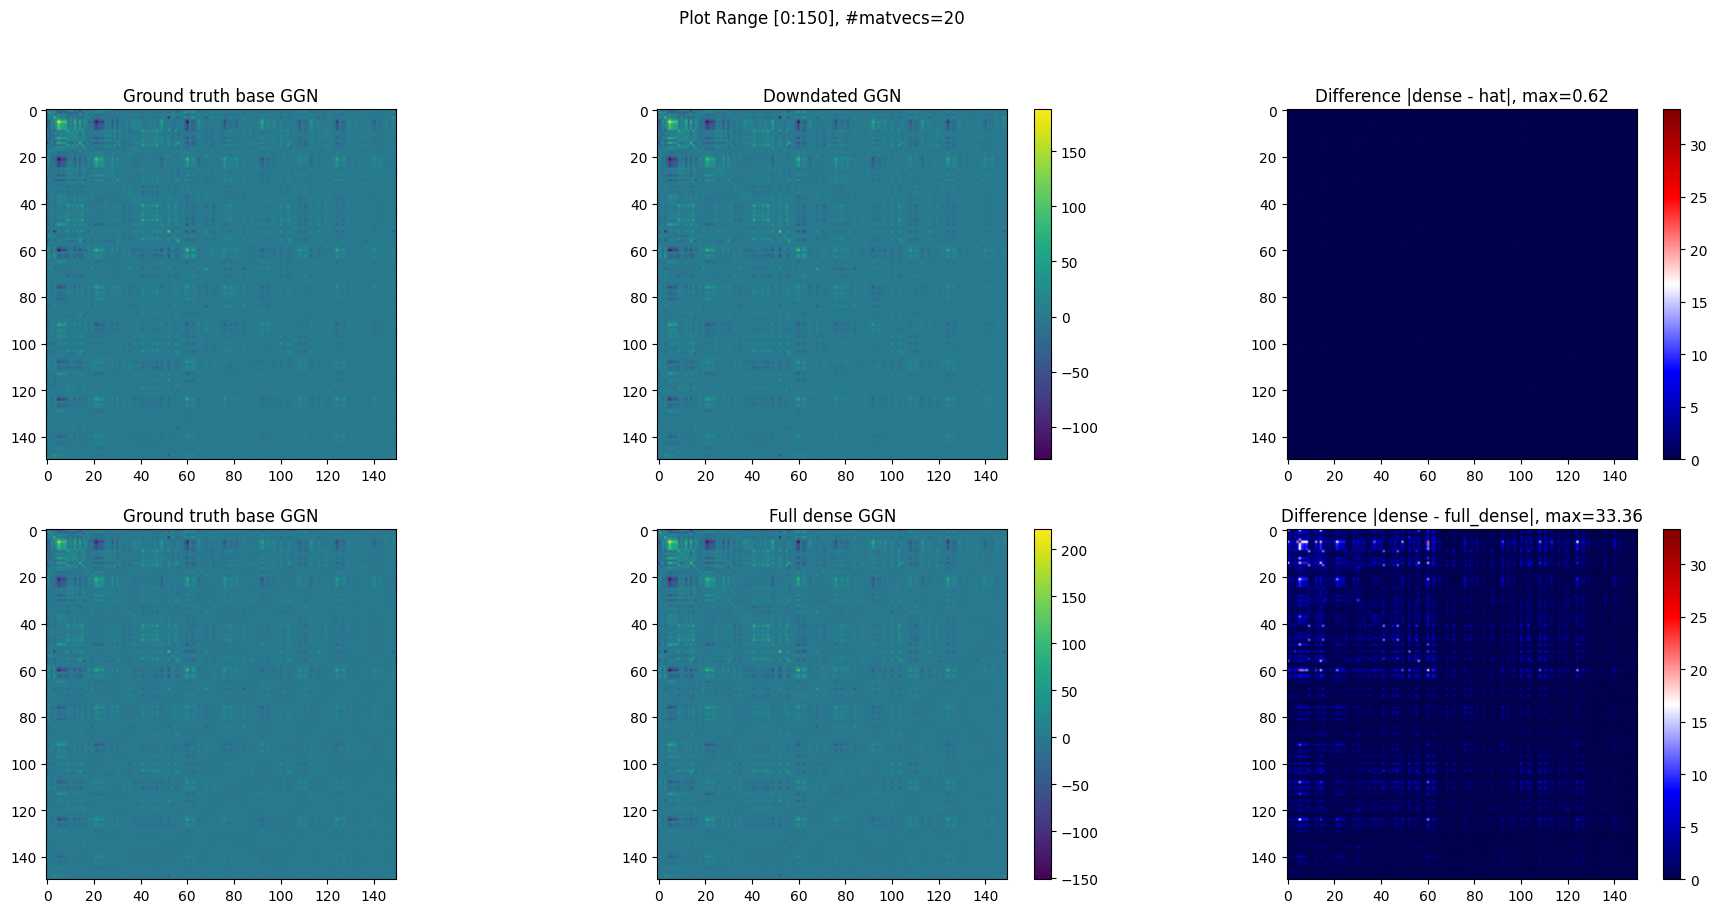

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(23, 10))

#* set a smaller range
_start = 000
_end   = 150

_GGN_dense      = GGN_dense[_start:_end, _start:_end]
_GGN_hat        = GGN_hat[_start:_end, _start:_end]
_GGN_full_dense = GGN_full_dense[_start:_end, _start:_end]  # <- assumes you have GGN_full_dense

diff_1 = jnp.abs(_GGN_dense - _GGN_hat)
diff_2 = jnp.abs(_GGN_dense - _GGN_full_dense)
vmax_diff = max(diff_1.max(), diff_2.max())

# --- Row 1: dense vs hat ---

vmin_1 = min(_GGN_hat.min(), _GGN_dense.min())
vmax_1 = max(_GGN_hat.max(), _GGN_dense.max())

im00 = axs[0, 0].imshow(_GGN_dense, vmin=vmin_1, vmax=vmax_1)
im01 = axs[0, 1].imshow(_GGN_hat,   vmin=vmin_1, vmax=vmax_1)
fig.colorbar(im01, ax=axs[0, 1])

im02 = axs[0, 2].imshow(diff_1, cmap='seismic', vmin=0, vmax=vmax_diff)
fig.colorbar(im02, ax=axs[0, 2])

axs[0, 0].set_title(f'Ground truth base GGN')
axs[0, 1].set_title(f'Downdated GGN')
axs[0, 2].set_title(f'Difference |dense - hat|, max={diff_1.max():.2f}')

# --- Row 2: dense vs full_dense ---


vmin_2 = min(_GGN_full_dense.min(), _GGN_dense.min())
vmax_2 = max(_GGN_full_dense.max(), _GGN_dense.max())

im10 = axs[1, 0].imshow(_GGN_dense,      vmin=vmin_2, vmax=vmax_2)
im11 = axs[1, 1].imshow(_GGN_full_dense, vmin=vmin_2, vmax=vmax_2)
fig.colorbar(im11, ax=axs[1, 1])

im12 = axs[1, 2].imshow(diff_2, cmap='seismic', vmin=0, vmax=vmax_diff)
fig.colorbar(im12, ax=axs[1, 2])

axs[1, 0].set_title(f'Ground truth base GGN')
axs[1, 1].set_title(f'Full dense GGN')
axs[1, 2].set_title(f'Difference |dense - full_dense|, max={diff_2.max():.2f}')

plt.suptitle(f"Plot Range [{_start}:{_end}], #matvecs={M}")
# plt.tight_layout()
plt.show()


In [ ]:
iso_prior = alpha*jnp.eye(D)

_,ld0 = jnp.linalg.slogdet(   iso_prior + GGN_dense)        # A - ww^T
s0, res0 = jnp.linalg.slogdet(iso_prior + GGN_hat) # \tilde{X}\tilde{X}^T

print(f"True logdet (GGN)     = {ld0:.1f}")
print(f"Recon logdet(GGN_hat) = {s0*res0:.1f}")

True logdet (GGN)     = -2135.8
Recon logdet(GGN_hat) = -2176.3


## Test execution time between the full GGN and the single data point ones

In [ ]:
import time

rtry = 20_000

key = jax.random.PRNGKey(41344143322)
Vs  = jax.random.normal(key, (D, rtry), dtype=flat_params.dtype)

# JIT batched versions (batch over columns)
batched_full  = jax.jit(lambda V: jax.vmap(GGN,  in_axes=1, out_axes=1)(V))
batched_wtp   = jax.jit(lambda V: jax.vmap(WTp,  in_axes=1, out_axes=1)(V))

# Warmup/compile (exclude compilation from timing)
_ = batched_full(Vs[:, :8]).block_until_ready()
_ = batched_wtp(Vs[:,  :8]).block_until_ready()

# Time 1000 applications
t0 = time.perf_counter(); _ = batched_full(Vs).block_until_ready(); t_full = time.perf_counter() - t0
t0 = time.perf_counter(); _ = batched_wtp(Vs).block_until_ready(); t_wtp  = time.perf_counter() - t0

print(f"Full GGN  : {rtry:4d} matvecs in {t_full:8.4f}s  -> {rtry/t_full:8.1f} /s")
print(f"WTp (small): {rtry:4d} calls   in {t_wtp :8.4f}s  -> {rtry/t_wtp :8.1f} /s")
print(f"Estimated speedup (WTp vs GGN): x{t_full/t_wtp:,.2f}")

Full GGN  : 20000 matvecs in   3.5889s  ->   5572.8 /s
WTp (small): 20000 calls   in   0.2001s  ->  99928.3 /s
Estimated speedup (WTp vs GGN): x17.93


In [ ]:
# Sequential JITted calls wrapped in a fori_loop and reduced to a scalar to ensure work is done
jit_full = jax.jit(GGN)
jit_wtp  = jax.jit(WTp)

def loop_sum(op, V):
    def body(i, acc):
        return acc + jnp.sum(op(V[:, i]))
    return jax.lax.fori_loop(0, V.shape[1], body, 0.0)

seq_full = jax.jit(lambda V: loop_sum(jit_full, V))
seq_wtp  = jax.jit(lambda V: loop_sum(jit_wtp,  V))

# warmup
_ = seq_full(Vs[:, :8]).block_until_ready()
_ = seq_wtp (Vs[:, :8]).block_until_ready()

t0 = time.perf_counter(); _ = seq_full(Vs).block_until_ready(); t_full_seq = time.perf_counter() - t0
t0 = time.perf_counter(); _ = seq_wtp (Vs).block_until_ready(); t_wtp_seq  = time.perf_counter() - t0

print(f"[seq] Full GGN : {rtry} in {t_full_seq:8.4f}s -> {rtry/t_full_seq:8.1f} /s")
print(f"[seq] WTp      : {rtry} in {t_wtp_seq :8.4f}s -> {rtry/t_wtp_seq :8.1f} /s")
print(f"[seq] Speedup  : x{t_full_seq/t_wtp_seq:,.2f}")


[seq] Full GGN : 20000 in   9.4226s ->   2122.6 /s
[seq] WTp      : 20000 in   1.0789s ->  18537.8 /s
[seq] Speedup  : x8.73
